# Weather Rain Prediction — พรุ่งนี้จะฝนตกมั้ย?


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RNG = 42

## 2. Load & Prepare Data

In [12]:
try:
    df_model = bangkok_df.copy()
    print('Loaded bangkok_df from memory')
except NameError:
    df_model = pd.read_csv('Cleaned_Weather_Data.csv')
    print('Loaded from CSV')

# Encode season as numeric
df_model['season_enc'] = df_model['month'].apply(
    lambda m: 0 if m in [11,12,1,2] else (1 if m in [3,4,5] else 2))
# 0 = Cool (Nov–Feb), 1 = Hot (Mar–May), 2 = Rainy (Jun–Oct)

df_model['pm_lag']       = df_model['air_quality_PM2.5'].shift(1)
df_model['wind_lag']     = df_model['wind_kph'].shift(1)
df_model['uv_lag']       = df_model['uv_index'].shift(1)
df_model['humidity_lag'] = df_model['humidity'].shift(1)
df_model['cloud_lag']    = df_model['cloud'].shift(1)
df_model['is_day']       = df_model['hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)

df_model['date'] = pd.to_datetime(df_model[['year', 'month', 'day']])
df_model = (df_model.sort_values('date')
            .drop_duplicates('date', keep='last')
            .reset_index(drop=True))
df_model = df_model.replace([np.inf, -np.inf], np.nan)
num_cols = df_model.select_dtypes(include=[np.number]).columns
df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())

print(f'Rows: {len(df_model)}  |  {df_model["date"].min().date()} to {df_model["date"].max().date()}')
print('\nCondition distribution:')
print(df_model['condition_text'].value_counts())

Loaded from CSV
Rows: 707  |  2024-05-16 to 2026-04-27

Condition distribution:
condition_text
Cloudy     444
Clear      160
Rain        67
Thunder     33
Drizzle      3
Name: count, dtype: int64


## 3. Create Target 

In [ ]:
# Target: 1 = ฝนพรุ่งนี้ (Rain/Thunder/Drizzle), 0 = ไม่ฝน
# shift(-1) = เอาค่าวันถัดไปมาเป็น target ของวันนี้
df_model['rain_tomorrow'] = (
    df_model['condition_text']
    .isin(['Rain', 'Thunder', 'Drizzle'])
    .astype(int)
    .shift(-1)
)
df_model = df_model.dropna(subset=['rain_tomorrow'])
df_model['rain_tomorrow'] = df_model['rain_tomorrow'].astype(int)

print('Target distribution:')
print(df_model['rain_tomorrow'].value_counts().rename({0: 'No Rain (0)', 1: 'Rain (1)'}))
print(f'\nRain ratio: {df_model["rain_tomorrow"].mean():.1%}')

Target distribution:
rain_tomorrow
No Rain (0)    603
Rain (1)       103
Name: count, dtype: int64

Rain ratio: 14.6%


## 4. Feature Engineering

In [4]:
LAG_COLS = ['temperature_celsius', 'humidity', 'wind_kph', 'precip_mm',
            'pressure_mb', 'cloud', 'uv_index']

def add_features(d):
    d = d.copy()
    # Seasonal cycle features
    d['dayofyear'] = d['date'].dt.dayofyear
    d['doy_sin']   = np.sin(2 * np.pi * d['dayofyear'] / 365.25)
    d['doy_cos']   = np.cos(2 * np.pi * d['dayofyear'] / 365.25)
    # Lag and rolling features
    for c in LAG_COLS:
        for lag in [1, 2, 3, 7]:
            d[f'{c}_lag{lag}'] = d[c].shift(lag)
        d[f'{c}_roll3'] = d[c].shift(1).rolling(3).mean()
        d[f'{c}_roll7'] = d[c].shift(1).rolling(7).mean()
    # Trend features — capture direction of change
    d['pressure_trend1'] = d['pressure_mb'] - d['pressure_mb'].shift(1)
    d['pressure_trend3'] = d['pressure_mb'] - d['pressure_mb'].shift(3)
    d['pressure_trend7'] = d['pressure_mb'] - d['pressure_mb'].shift(7)
    d['humidity_trend1'] = d['humidity'] - d['humidity'].shift(1)
    d['humidity_trend3'] = d['humidity'] - d['humidity'].shift(3)
    d['cloud_trend3']    = d['cloud'] - d['cloud'].shift(3)
    # Accumulated precipitation
    d['precip_sum3'] = d['precip_mm'].shift(1).rolling(3).sum()
    d['precip_sum7'] = d['precip_mm'].shift(1).rolling(7).sum()
    return d

feat = add_features(df_model)
print('After feature engineering:', feat.shape)

After feature engineering: (706, 87)


## 5. Train / Test Split

In [ ]:
#rain ข้อมูลก่อน ก.ย. 2025
#Test (180 วัน) — ก.ย. 2025 – ก.พ. 2026 ครอบคลุมทั้งหน้าฝนและหน้าแล้ง
#เหตุผลที่ไม่ใช้แค่ 14 วัน เพราะช่วง Apr 11–24 ไม่มีฝนเลย
#ทำให้ประเมิน F1-ฝนไม่ได้ จึงขยาย window ให้ครอบคลุมช่วงที่มีฝนด้วย

TEST_START = pd.Timestamp('2025-09-01')
TEST_END   = pd.Timestamp('2026-02-28')

all_drop = [c for c in feat.columns
            if '_lag' in c or '_roll' in c or '_trend' in c or '_sum' in c]
data = feat.dropna(subset=all_drop).reset_index(drop=True)

train_all  = data[data['date'] < TEST_START].copy().reset_index(drop=True)
test_clean = data[(data['date'] >= TEST_START) & (data['date'] <= TEST_END)].copy().reset_index(drop=True)

print(f'Train : {len(train_all)} days  ({train_all["date"].min().date()} to {train_all["date"].max().date()})')
print(f'Test  : {len(test_clean)} days  ({test_clean["date"].min().date()} to {test_clean["date"].max().date()})')
print(f'  Rain in train : {train_all["rain_tomorrow"].sum()}/{len(train_all)} days ({train_all["rain_tomorrow"].mean():.1%})')
print(f'  Rain in test  : {test_clean["rain_tomorrow"].sum()}/{len(test_clean)} days ({test_clean["rain_tomorrow"].mean():.1%})')

LEAK = {'date', 'condition_text', 'condition_name', 'moon_phase',
        'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
        'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
        'air_quality_PM2.5', 'air_quality_PM10',
        'air_quality_us-epa-index', 'air_quality_gb-defra-index',
        'moon_illumination',
        'Humidity_over_Cloud', 'Humidity_over_Temp',
        'Humidity_over_Visibility', 'Gust_over_Wind', 'rain_tomorrow'}
# Predicting tomorrow: only lag/roll/trend features allowed
# (we cannot use today's values when predicting tomorrow)
CURRENT_DAY_RAW = {
    'temperature_celsius', 'humidity', 'wind_kph', 'precip_mm',
    'pressure_mb', 'cloud', 'uv_index', 'gust_kph',
    'feels_like_celsius', 'visibility_km', 'dew_point_celsius',
    'windchill_celsius', 'heatindex_celsius'
}
FEATURES = [c for c in data.columns
            if c not in LEAK and c not in CURRENT_DAY_RAW
            and data[c].dtype != 'object']
print(f'\nTotal features: {len(FEATURES)}')

Train : 462 days  (2024-05-24 to 2025-08-31)
Test  : 180 days  (2025-09-01 to 2026-02-28)
  Rain in train : 74/462 days (16.0%)
  Rain in test  : 22/180 days (12.2%)

Total features: 64


## 6. XGBoost Model + 5-Fold Time-Series CV

In [ ]:
#รอบ 1–4 : ทดสอบบน train data แบ่งเป็น 4 ช่วง
#รอบ 5   : train ทั้งหมด → test 180 วันจริง (ก.ย. 2025 – ก.พ. 2026)

n_no      = (train_all['rain_tomorrow'] == 0).sum()
n_yes     = (train_all['rain_tomorrow'] == 1).sum()
scale_pos = n_no / n_yes
print(f'Class ratio (No Rain : Rain) = {n_no} : {n_yes}  |  scale_pos_weight = {scale_pos:.1f}')

def make_xgb():
    return XGBClassifier(
        objective='binary:logistic',
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        random_state=RNG,
        n_jobs=-1,
        verbosity=0
    )

N = len(train_all)
FOLD_SZ = N // 5

print('\n' + '='*65)
print('5-Fold Time-Series CV — Predict Rain Tomorrow')
print('='*65)

cv_rows = []
for k in range(1, 5):
    tr_fold  = train_all.iloc[:k * FOLD_SZ]
    val_fold = train_all.iloc[k * FOLD_SZ : min((k+1) * FOLD_SZ, N)]
    clf_fold = make_xgb()
    clf_fold.fit(tr_fold[FEATURES], tr_fold['rain_tomorrow'])
    preds = clf_fold.predict(val_fold[FEATURES])
    acc = accuracy_score(val_fold['rain_tomorrow'], preds)
    f1  = f1_score(val_fold['rain_tomorrow'], preds, zero_division=0)
    rain_days = val_fold['rain_tomorrow'].sum()
    cv_rows.append({'fold': k, 'accuracy': acc, 'f1_rain': f1})
    print(f'  Fold {k}: Acc={acc:.3f}  F1-Rain={f1:.3f}  '
          f'({val_fold["date"].min().date()} to {val_fold["date"].max().date()})  '
          f'Rain {rain_days}/{len(val_fold)} days')

# Fold 5 = actual test set
clf = make_xgb()
clf.fit(train_all[FEATURES], train_all['rain_tomorrow'])
pred_test = clf.predict(test_clean[FEATURES])
acc5 = accuracy_score(test_clean['rain_tomorrow'], pred_test)
f1_5 = f1_score(test_clean['rain_tomorrow'], pred_test, zero_division=0)
cv_rows.append({'fold': 5, 'accuracy': acc5, 'f1_rain': f1_5})
print(f'  Fold 5: Acc={acc5:.3f}  F1-Rain={f1_5:.3f}  '
      f'({test_clean["date"].min().date()} to {test_clean["date"].max().date()})  '
      f'Rain {test_clean["rain_tomorrow"].sum()}/{len(test_clean)} days  < ACTUAL TEST')

cv_df = pd.DataFrame(cv_rows)
print('='*65)
print(f'  Mean: Acc={cv_df["accuracy"].mean():.3f} +/- {cv_df["accuracy"].std():.3f}')
print(f'  Mean: F1 ={cv_df["f1_rain"].mean():.3f} +/- {cv_df["f1_rain"].std():.3f}')

Class ratio (No Rain : Rain) = 388 : 74  |  scale_pos_weight = 5.2

5-Fold Time-Series CV — Predict Rain Tomorrow
  Fold 1: Acc=0.696  F1-Rain=0.222  (2024-08-27 to 2024-11-26)  Rain 22/92 days
  Fold 2: Acc=0.989  F1-Rain=0.000  (2024-11-27 to 2025-02-26)  Rain 0/92 days
  Fold 3: Acc=0.837  F1-Rain=0.118  (2025-02-27 to 2025-05-29)  Rain 16/92 days
  Fold 4: Acc=0.804  F1-Rain=0.100  (2025-05-30 to 2025-08-29)  Rain 16/92 days
  Fold 5: Acc=0.861  F1-Rain=0.074  (2025-09-01 to 2026-02-28)  Rain 22/180 days  < ACTUAL TEST
  Mean: Acc=0.837 +/- 0.106
  Mean: F1 =0.103 +/- 0.080


## 7. Detailed Results

In [7]:
print('=== Classification Report (Test: 180 days) ===')
print(classification_report(test_clean['rain_tomorrow'], pred_test,
      target_names=['No Rain', 'Rain'], zero_division=0))

# Monthly breakdown
test_clean = test_clean.copy()
test_clean['pred'] = pred_test
test_clean['ym']   = test_clean['date'].dt.to_period('M')
print('=== Monthly Breakdown ===')
for ym, g in test_clean.groupby('ym'):
    acc_m  = accuracy_score(g['rain_tomorrow'], g['pred'])
    f1_m   = f1_score(g['rain_tomorrow'], g['pred'], zero_division=0)
    rain_m = g['rain_tomorrow'].sum()
    pred_m = g['pred'].sum()
    print(f'  {ym}:  Acc={acc_m:.3f}  F1-Rain={f1_m:.3f}  '
          f'Actual rain={rain_m}/{len(g)} days  Predicted rain={pred_m} days')

=== Classification Report (Test: 180 days) ===
              precision    recall  f1-score   support

     No Rain       0.88      0.97      0.92       158
        Rain       0.20      0.05      0.07        22

    accuracy                           0.86       180
   macro avg       0.54      0.51      0.50       180
weighted avg       0.80      0.86      0.82       180

=== Monthly Breakdown ===
  2025-09:  Acc=0.800  F1-Rain=0.000  Actual rain=6/30 days  Predicted rain=0 days
  2025-10:  Acc=0.645  F1-Rain=0.154  Actual rain=11/31 days  Predicted rain=2 days
  2025-11:  Acc=0.767  F1-Rain=0.000  Actual rain=4/30 days  Predicted rain=3 days
  2025-12:  Acc=0.968  F1-Rain=0.000  Actual rain=1/31 days  Predicted rain=0 days
  2026-01:  Acc=1.000  F1-Rain=0.000  Actual rain=0/30 days  Predicted rain=0 days
  2026-02:  Acc=1.000  F1-Rain=0.000  Actual rain=0/28 days  Predicted rain=0 days


## 8. Visualizations

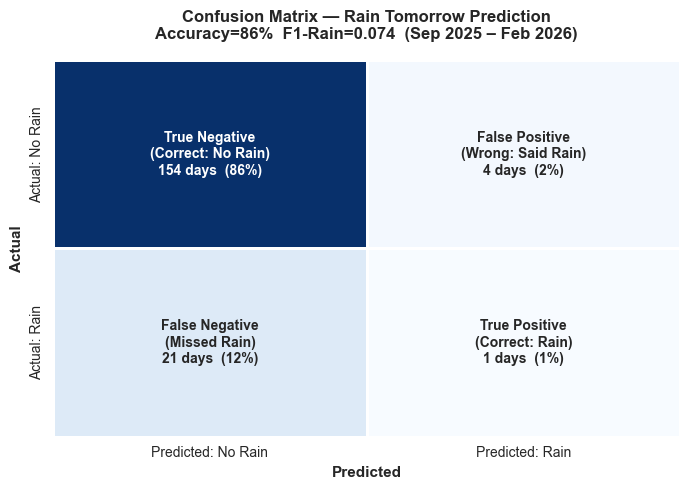

In [8]:
# Confusion Matrix
cm = confusion_matrix(test_clean['rain_tomorrow'], pred_test)
n_total = cm.sum()

annot = np.empty_like(cm, dtype=object)
labels_cm = [['True Negative\n(Correct: No Rain)', 'False Positive\n(Wrong: Said Rain)'],
             ['False Negative\n(Missed Rain)', 'True Positive\n(Correct: Rain)']]
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct = count / n_total * 100
        annot[i, j] = f'{labels_cm[i][j]}\n{count} days  ({pct:.0f}%)'

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=['Predicted: No Rain', 'Predicted: Rain'],
            yticklabels=['Actual: No Rain', 'Actual: Rain'],
            cbar=False, linewidths=2, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'}, ax=ax)
ax.set_title(f'Confusion Matrix — Rain Tomorrow Prediction\n'
             f'Accuracy={acc5:.0%}  F1-Rain={f1_5:.3f}  '
             f'(Sep 2025 – Feb 2026)',
             fontweight='bold', fontsize=12, pad=15)
ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

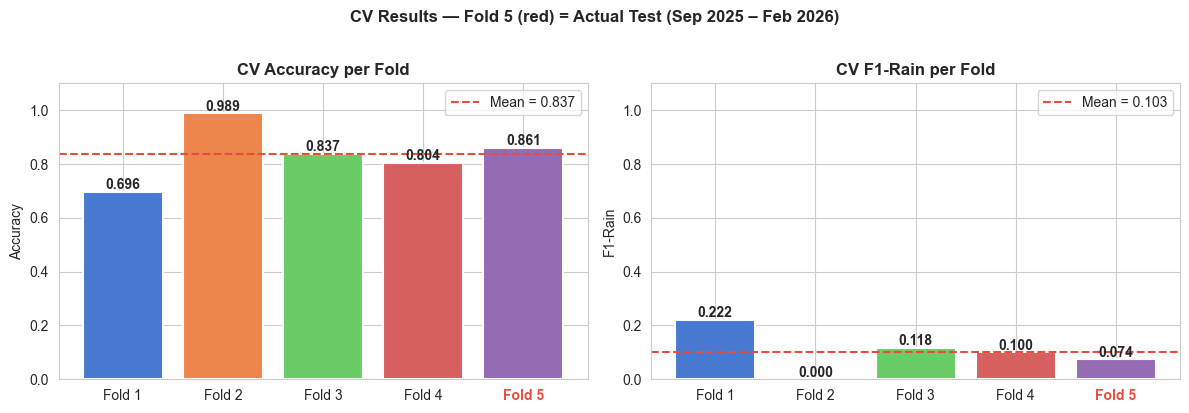

In [9]:
# CV Results per Fold
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = sns.color_palette('muted', len(cv_df))
fold_labels = [f'Fold {i}' for i in cv_df['fold']]

for ax, metric, title in zip(axes,
                              ['accuracy', 'f1_rain'],
                              ['Accuracy', 'F1-Rain']):
    bars = ax.bar(fold_labels, cv_df[metric], color=colors,
                  edgecolor='white', linewidth=1.5)
    ax.axhline(cv_df[metric].mean(), color='#e74c3c', linestyle='--',
               linewidth=1.5, label=f'Mean = {cv_df[metric].mean():.3f}')
    for bar, val in zip(bars, cv_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'CV {title} per Fold', fontweight='bold')
    ax.set_ylabel(title); ax.set_ylim(0, 1.1); ax.legend()
    ax.get_xticklabels()[-1].set_color('#e74c3c')
    ax.get_xticklabels()[-1].set_fontweight('bold')

plt.suptitle('CV Results — Fold 5 (red) = Actual Test (Sep 2025 – Feb 2026)',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

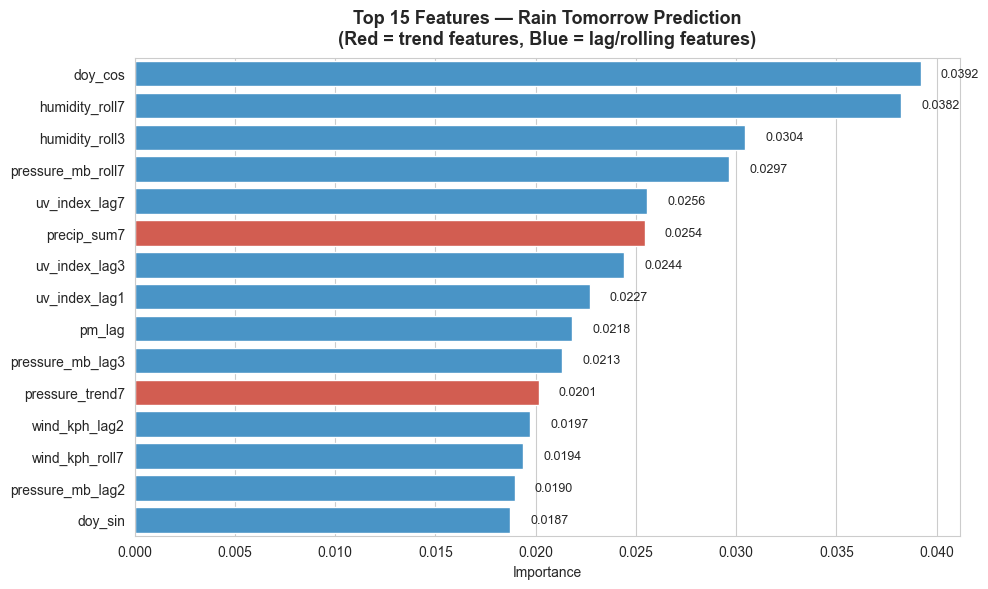

In [10]:
# Top 15 Feature Importance
imp = (pd.Series(clf.feature_importances_, index=FEATURES)
       .sort_values(ascending=False).head(15))

plt.figure(figsize=(10, 6))
colors_imp = ['#e74c3c' if '_trend' in c or '_sum' in c else '#3498db'
              for c in imp.index]
ax = sns.barplot(x=imp.values, y=imp.index, palette=colors_imp)
for i, v in enumerate(imp.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.title('Top 15 Features — Rain Tomorrow Prediction\n'
          '(Red = trend features, Blue = lag/rolling features)',
          fontweight='bold', fontsize=13, pad=10)
plt.xlabel('Importance'); plt.ylabel('')
plt.tight_layout(); plt.show()